In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set standard seaborn theme for consistent, professional aesthetics
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore') # Ignores warning messages for a cleaner notebook output

In [2]:
# Load the dataset
df = pd.read_csv('spotify_dataset_cleand.csv') # Make sure this file is in your directory

print("Dataset Overview:")
print(df.info())

# Preprocessing: Encoding categorical variables to binary numerical formats for ML models
# df['ad_interaction'] = df['ad_interaction'].map({'Yes': 1, 'No': 0})
# df['subscription_status'] = df['subscription_status'].map({'Active': 1, 'Inactive': 0})
# df['ad_conversion_to_subscription'] = df['ad_conversion_to_subscription'].map({'Yes': 1, 'No': 0})

# # Drop irrelevant columns (e.g., old index columns)
# if 'Unnamed: 0' in df.columns:
#     df = df.drop(['Unnamed: 0'], axis=1)

# Display the cleaned dataframe ready for EDA (Exploratory Data Analysis)
df.head()

Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  str    
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  str    
 4   subscription_type               50000 non-null  str    
 5   subscription_status             50000 non-null  int64  
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  int64  
 9   ad_conversion_to_subscription   50000 non-null  int64  
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre           

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,1,0,0,0,0,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,1,0,0,1,0,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,1,0,0,1,1,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,1,1,0,0,0,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,1,0,0,0,0,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


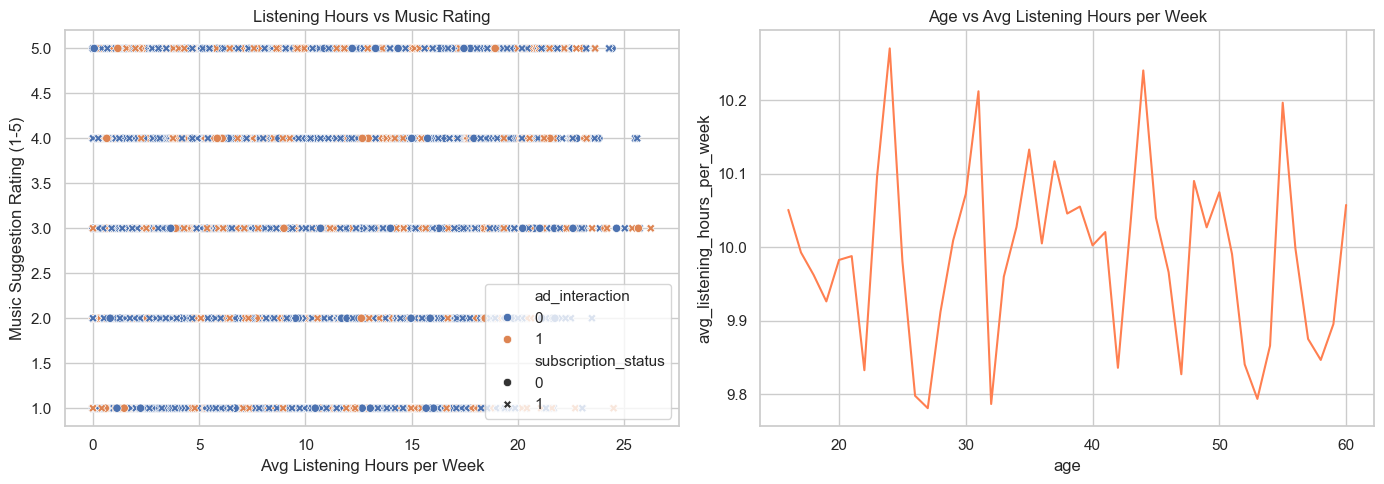

In [3]:
# Relational plots to understand continuous variables
plt.figure(figsize=(14, 5))

# Subplot 1: Scatterplot
plt.subplot(1, 2, 1)
sns.scatterplot(x='avg_listening_hours_per_week', y='music_suggestion_rating_1_to_5',hue='ad_interaction', style='subscription_status',
                 data=df)
plt.title("Listening Hours vs Music Rating")
plt.xlabel("Avg Listening Hours per Week")
plt.ylabel("Music Suggestion Rating (1-5)")

# Subplot 2: Lineplot
plt.subplot(1, 2, 2)
sns.lineplot(data=df, x='age', y='avg_listening_hours_per_week', errorbar=None, color='coral')
plt.title("Age vs Avg Listening Hours per Week")

plt.tight_layout()
plt.show()

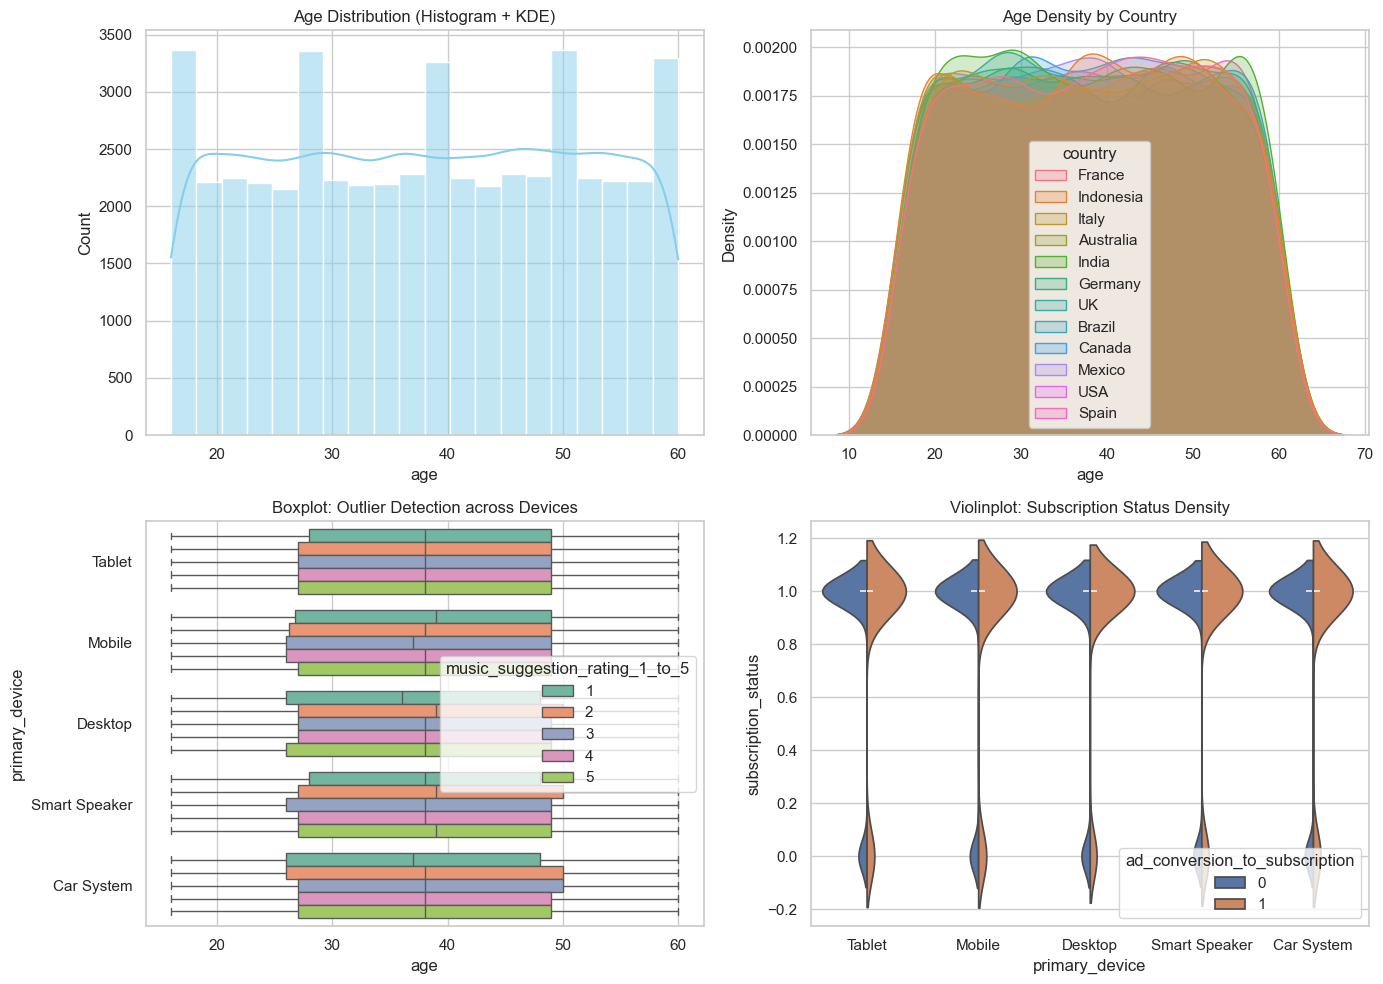

In [4]:
# Comprehensive Dashboard for Age and Device Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram with KDE: Shows the exact distribution of age
sns.histplot(df['age'], kde=True, bins=20, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution (Histogram + KDE)')

# KDE Plot: Age density by country
sns.kdeplot(data=df, x='age', hue='country', fill=True, ax=axes[0,1])
axes[0,1].set_title('Age Density by Country')

# Boxplot: Excellent for identifying outliers in features
sns.boxplot(x='age', y='primary_device', hue='music_suggestion_rating_1_to_5', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Boxplot: Outlier Detection across Devices')

# Violinplot: Shows distribution and probability density
sns.violinplot(x='primary_device', y='subscription_status', hue="ad_conversion_to_subscription", split=True, data=df, ax=axes[1, 1])
axes[1, 1].set_title("Violinplot: Subscription Status Density")

plt.tight_layout()
plt.show()

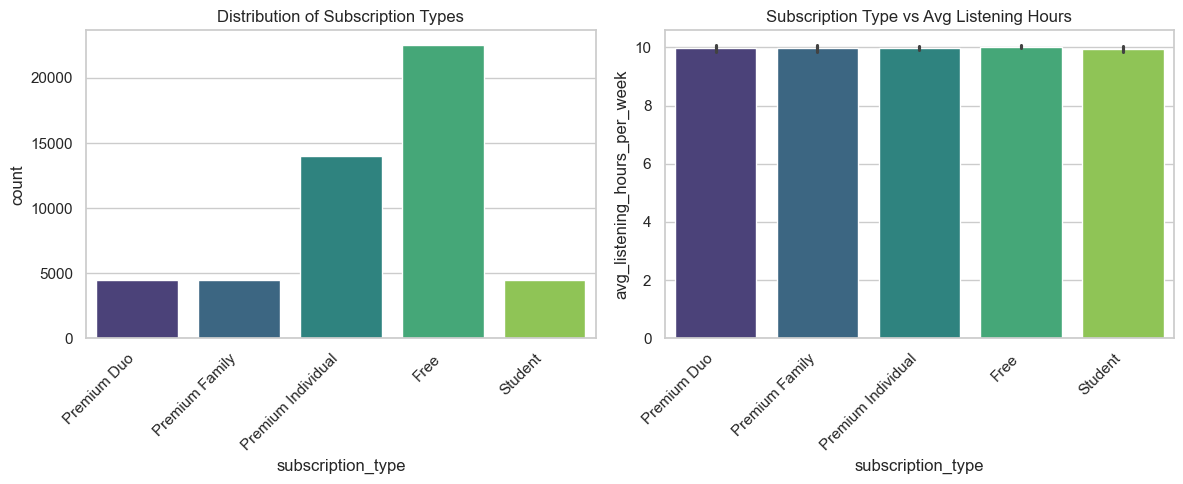

In [5]:
# Analyzing Categorical Features
plt.figure(figsize=(12, 5))

# Subplot 1: Count of each category
plt.subplot(1, 2, 1)
sns.countplot(x='subscription_type', data=df, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Subscription Types')

# Subplot 2: Barplot for average value across categories
plt.subplot(1, 2, 2)
sns.barplot(x='subscription_type', y='avg_listening_hours_per_week', data=df, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Subscription Type vs Avg Listening Hours')

plt.tight_layout()
plt.show()

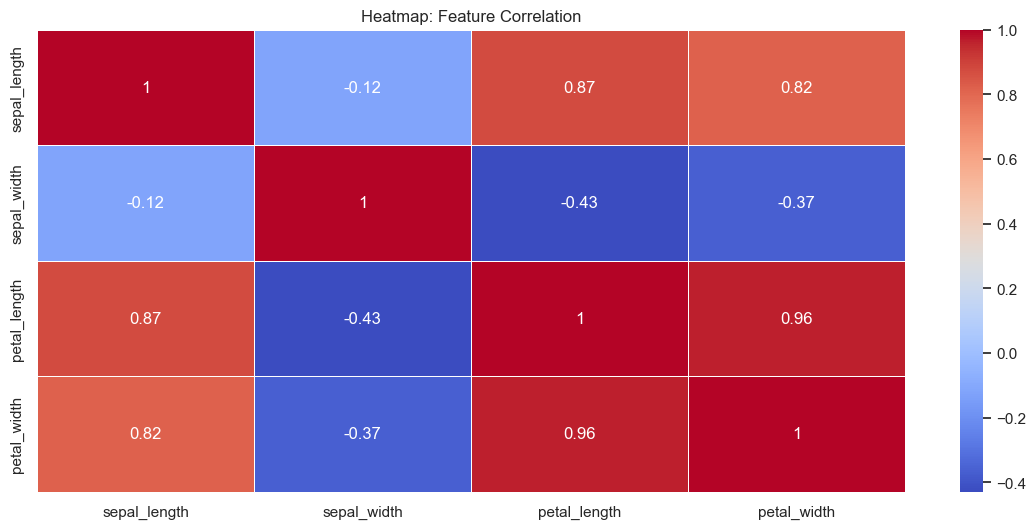

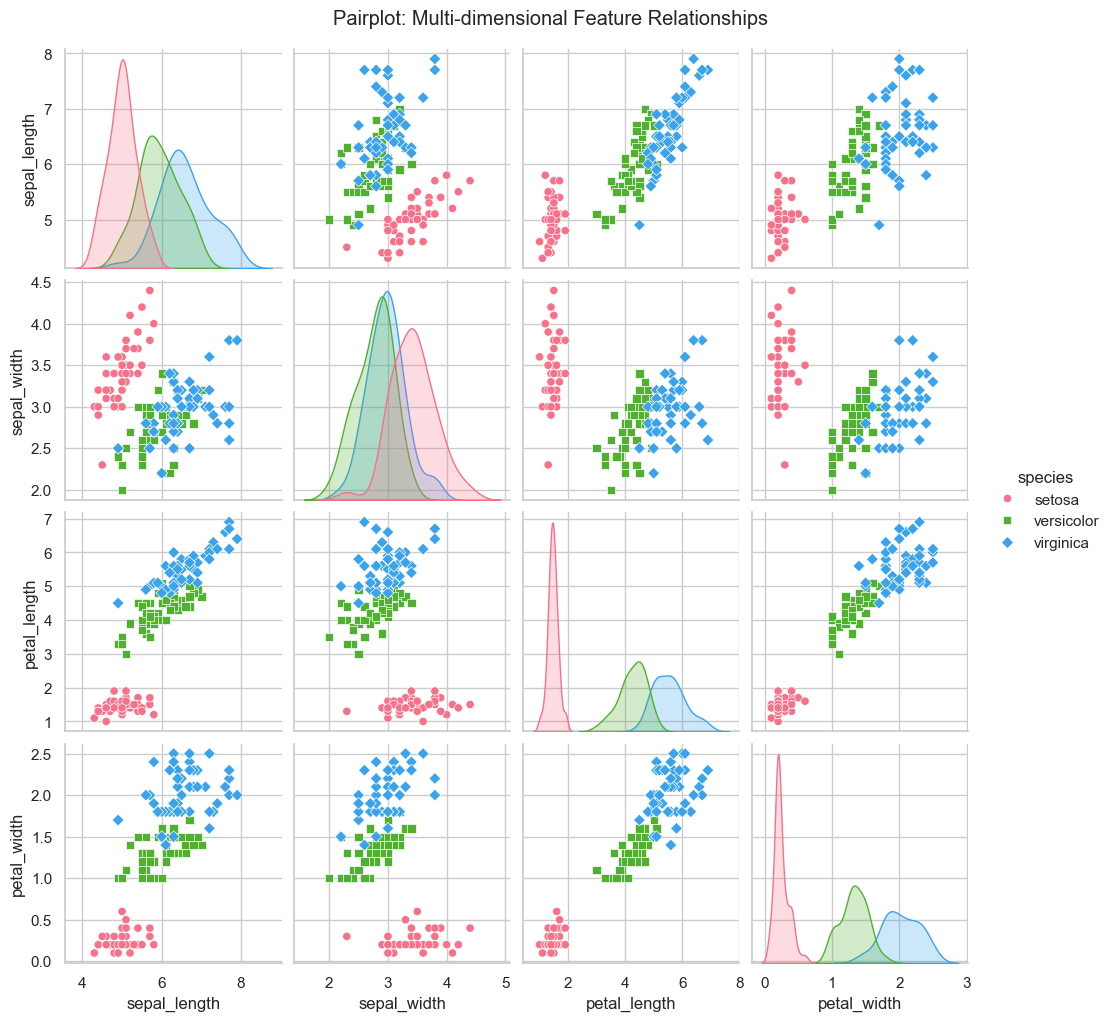

In [6]:
# Exploring Built-in Datasets for Correlation and Feature Grouping
iris = sns.load_dataset('iris')

# Select only numerical features for mathematical calculations
numeric_iris = iris.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 6))

# Heatmap: Identifies multicollinearity between features
sns.heatmap(numeric_iris.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap: Feature Correlation")

# Pairplot: Visualizes relationships across all dimensions
sns.pairplot(iris, hue='species', markers=["o", "s", "D"], palette='husl')
plt.suptitle("Pairplot: Multi-dimensional Feature Relationships", y=1.02)
plt.show()

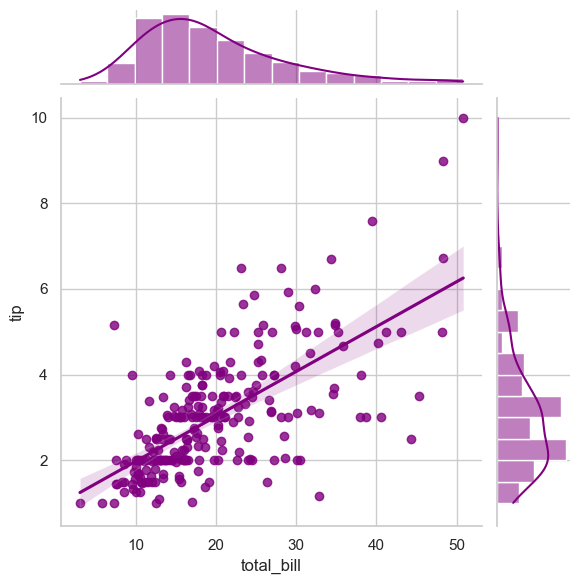

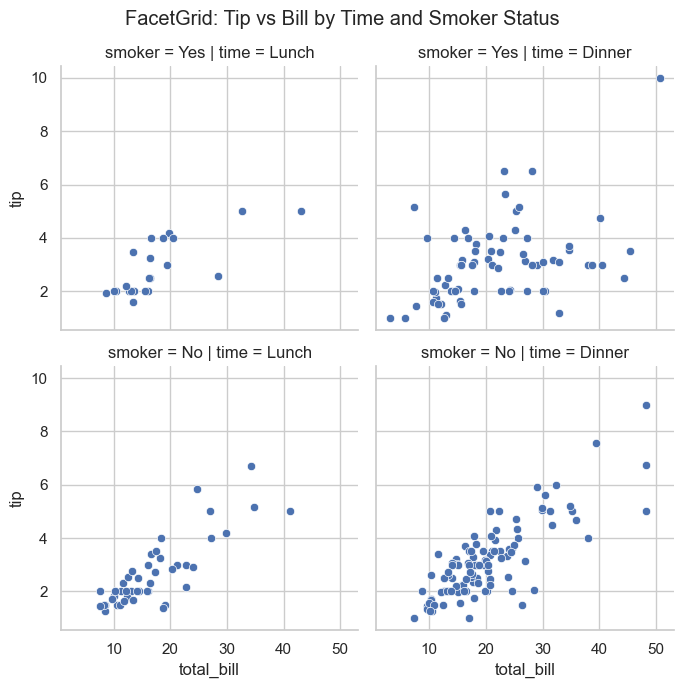

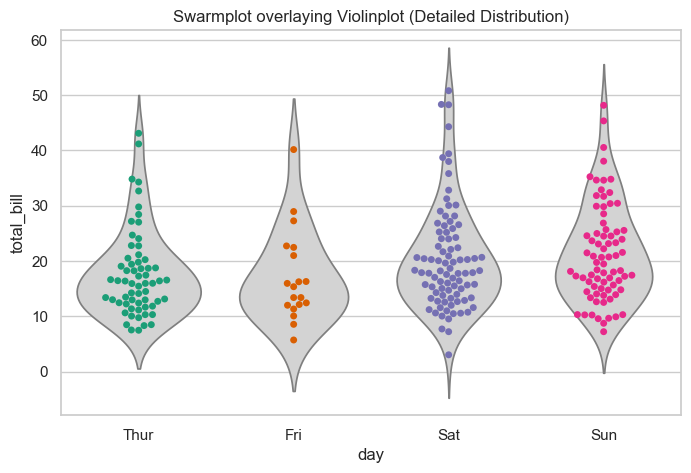

In [7]:
# Statistical Relationships and Multi-plot Grids
tips = sns.load_dataset('tips')

# Jointplot with Regression Line: Shows relationship and distribution simultaneously
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg', color='purple', height=6)
plt.show()

# FacetGrid: Multi-plot grid for conditioning on categorical variables
g = sns.FacetGrid(tips, col="time", row="smoker", height=3.5)
g.map(sns.scatterplot, "total_bill", "tip")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('FacetGrid: Tip vs Bill by Time and Smoker Status')
plt.show()

# Combining Violin and Swarm plots to see exact data points over distribution
plt.figure(figsize=(8, 5))
sns.violinplot(x='day', y='total_bill', data=tips, color='lightgray', inner=None)
sns.swarmplot(x='day', y='total_bill', data=tips, palette='Dark2', size=5)
plt.title("Swarmplot overlaying Violinplot (Detailed Distribution)")
plt.show()